In [2]:
import cv2
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
import os

top_path = "../data/top_view"
front_path = "../data/front_view"

print("Top View Videos:")
print(os.listdir(top_path))

print("\nFront View Videos:")
print(os.listdir(front_path))

Top View Videos:
['B90_Top.mp4', 'B91_Top.mp4', 'B92_Top.mp4', 'B93_Top.mp4']

Front View Videos:
['B90_Front.mp4', 'B91_Front.mp4', 'B92_Front.mp4', 'B93_Front.mp4']


In [4]:
import cv2
import os
import pandas as pd

video_info = []

folders = {
    "Top": "../data/top_view",
    "Front": "../data/front_view"
}

for view_type, folder in folders.items():
    
    for video_name in os.listdir(folder):
        
        video_path = os.path.join(folder, video_name)
        
        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        duration_sec = frame_count / fps

        video_info.append({
            "Video": video_name,
            "View": view_type,
            "FPS": round(fps, 2),
            "Duration (sec)": round(duration_sec, 2),
            "Resolution": f"{width}x{height}"
        })

        cap.release()

df = pd.DataFrame(video_info)

df

,Video,View,FPS,Duration (sec),Resolution
0,B90_Top.mp4,Top,25.00,2393.68,1920x1080
1,B91_Top.mp4,Top,25.00,2397.60,1920x1080
2,B92_Top.mp4,Top,25.00,2396.52,1920x1080
3,B93_Top.mp4,Top,25.00,2400.12,1920x1080
4,B90_Front.mp4,Front,24.91,2248.72,2688x1520
5,B91_Front.mp4,Front,24.94,2283.08,2688x1520
6,B92_Front.mp4,Front,25.00,2173.16,2688x1520
7,B93_Front.mp4,Front,24.97,2223.80,2688x1520


In [5]:
df.to_excel("../video_summary.xlsx", index=False)

print("Video summary saved successfully!")

Video summary saved successfully!


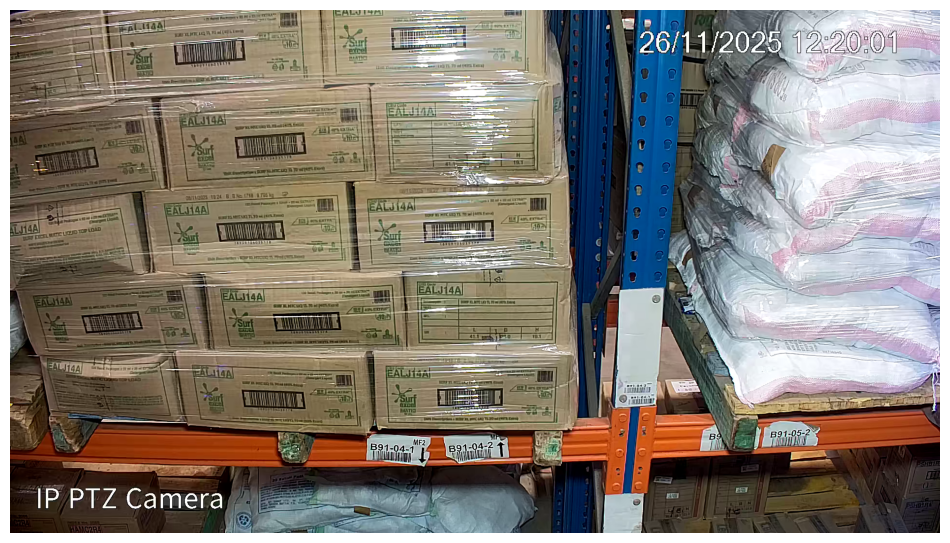

In [6]:
import cv2
import matplotlib.pyplot as plt

video_path = "../data/top_view/B90_Top.mp4"

cap = cv2.VideoCapture(video_path)

success, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

cap.release()

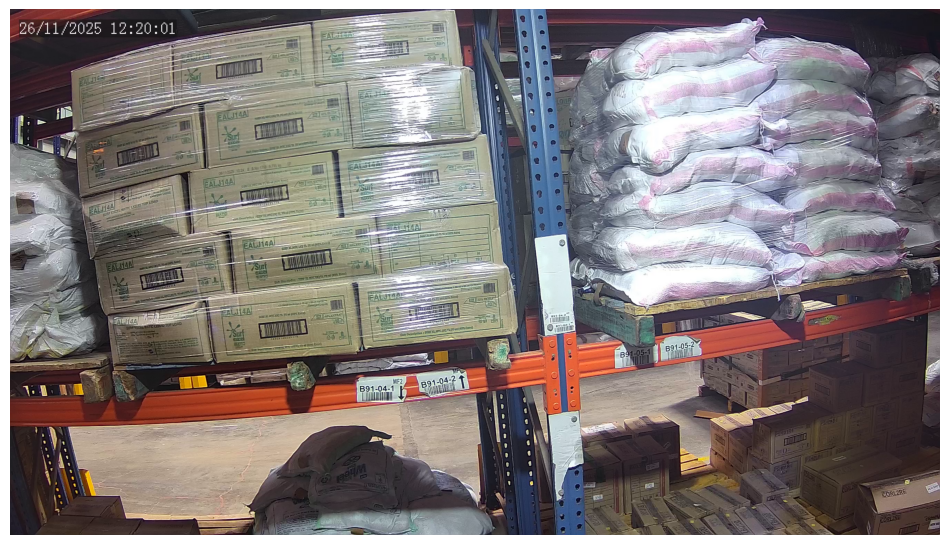

In [7]:
import cv2
import matplotlib.pyplot as plt

video_path = "../data/front_view/B90_Front.mp4"

cap = cv2.VideoCapture(video_path)

success, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

cap.release()

In [1]:
import cv2
import os

videos = [
    ("../data/front_view/B91_Front.mp4", "../data/extracted_frames/B91_Front"),
    ("../data/top_view/B91_Top.mp4", "../data/extracted_frames/B91_Top"),
    ("../data/front_view/B92_Front.mp4", "../data/extracted_frames/B92_Front"),
    ("../data/top_view/B92_Top.mp4", "../data/extracted_frames/B92_Top")
]

for video_path, output_folder in videos:

    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_interval = int(fps)   # 1 frame every second

    frame_count = 0
    saved_count = 0

    while True:

        success, frame = cap.read()

        if not success:
            break

        if frame_count % frame_interval == 0:

            filename = f"frame_{saved_count:04d}.jpg"

            cv2.imwrite(
                os.path.join(output_folder, filename),
                frame
            )

            saved_count += 1

        frame_count += 1

    cap.release()

    print(f"{os.path.basename(video_path)} -> {saved_count} frames saved")

print("Frame extraction completed!")

B91_Front.mp4 -> 2367 frames saved
B91_Top.mp4 -> 2398 frames saved
B92_Front.mp4 -> 2168 frames saved
B92_Top.mp4 -> 2397 frames saved
Frame extraction completed!


In [11]:
import cv2
import numpy as np

video_path = "../data/front_view/B91_Front.mp4"

cap = cv2.VideoCapture(video_path)

ret, prev_frame = cap.read()

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

motion_scores = []

while True:
    
    ret, frame = cap.read()
    
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(prev_gray, gray)

    score = np.mean(diff)

    motion_scores.append(score)

    prev_gray = gray

cap.release()

print("Average Motion Score:", np.mean(motion_scores))
print("Maximum Motion Score:", np.max(motion_scores))

Average Motion Score: 4.670305739983602
Maximum Motion Score: 67.65354964559837


In [3]:
def generate_rack_ids(section, start, end, exclude=None):
    exclude = exclude or []
    ids = []
    for n in range(start, end + 1):
        rack_id = f"{section}-{n:02d}-2"
        if rack_id not in exclude:
            ids.append(rack_id)
    return ids

b90_ids = generate_rack_ids("B90", 3, 31)
b91_ids = ["B90-03-2", "B90-04-2"] + generate_rack_ids("B91", 3, 31)
b92_ids = generate_rack_ids("B92", 3, 31, exclude=["B92-17-2"])
b93_ids = generate_rack_ids("B93", 3, 31)

section_counts = {"B90": len(b90_ids), "B91": len(b91_ids), "B92": len(b92_ids), "B93": len(b93_ids)}
print(section_counts)
print("Total racks:", sum(section_counts.values()))

all_rack_ids = b90_ids + b91_ids + b92_ids + b93_ids
import pandas as pd
df = pd.DataFrame({"rack_id": all_rack_ids})
df["section"] = df["rack_id"].str.split("-").str[0]
df.to_csv("../Data/Full_rack_list.csv", index=False)

{'B90': 29, 'B91': 31, 'B92': 28, 'B93': 29}
Total racks: 117


In [1]:
import easyocr
import pandas as pd
import os

reader = easyocr.Reader(['en'])

folder = "../Data/ocr_test"

results = []

for file in os.listdir(folder):

    path = os.path.join(folder, file)

    ocr_result = reader.readtext(path)

    detected_text = " ".join([r[1] for r in ocr_result])

    confidence = max([r[2] for r in ocr_result], default=0)

    results.append({
        "Image": file,
        "OCR_Output": detected_text,
        "Confidence": round(confidence,3)
    })

df = pd.DataFrame(results)

print(df)

df.to_excel("../Data/ocr_feasibility_results.xlsx", index=False)

print("Results saved!")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

c:\Users\najna\miniconda3\envs\warehouse_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\najna\miniconda3\envs\warehouse_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\najna\miniconda3\envs\warehouse_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


        Image                   OCR_Output  Confidence
0  label1.jpg  M8z M8X B90-04-1 M B90-04-2       0.989
1  label2.jpg            891-06-1 B91-06-2       0.922
2  label3.jpg                                    0.000
3  label4.jpg                 27 @cou Codo       0.179
4  label5.jpg                                    0.000
5  label6.jpg                                    0.000
Results saved!
